# Festive-Season (Diwali) Retail Sales Analysis
**Business question:** Who spends the most during Diwali, where, and on what, so a retailer can target campaigns and plan stock?

**Tools:** Python, pandas, Matplotlib, Plotly (Google Colab)
**Flow:** load data, clean data, answer 13 business questions with charts, then summarize findings and recommendations.

In [1]:
import pandas as pd


## Load the data
Upload `Diwali Sales Data.csv` to the Colab sidebar first (folder icon > upload icon), then run the next cell.

In [2]:
Diwali_df = pd.read_csv('Diwali Sales Data.csv', encoding='latin-1')

In [3]:
display(Diwali_df)

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370.0,NaN,NaN
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367.0,NaN,NaN
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213.0,NaN,NaN
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206.0,NaN,NaN


# **Data Cleaning**
Before analysis, check the shape, missing values, duplicates, and data types, then fix what is wrong.

In [4]:
print('Shape:', Diwali_df.shape)
print()
Diwali_df.info()
print()
print('Missing values per column:')
print(Diwali_df.isnull().sum())
print()
print('Duplicate rows:', Diwali_df.duplicated().sum())

Shape: (11251, 15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB

Missing v

In [5]:
# 1. Drop empty / unused columns if they exist (e.g. 'Status', 'unnamed1' in this dataset)
cols_to_drop = [c for c in Diwali_df.columns if c.lower().startswith('unnamed') or c in ['Status']]
Diwali_df = Diwali_df.drop(columns=cols_to_drop, errors='ignore')
print('Dropped columns:', cols_to_drop)

# 2. Make sure Amount is numeric, then drop rows where Amount is missing
Diwali_df['Amount'] = pd.to_numeric(Diwali_df['Amount'], errors='coerce')
before = len(Diwali_df)
Diwali_df = Diwali_df.dropna(subset=['Amount'])
print('Rows dropped (missing Amount):', before - len(Diwali_df))

# 3. Remove duplicate rows
before = len(Diwali_df)
Diwali_df = Diwali_df.drop_duplicates()
print('Duplicate rows removed:', before - len(Diwali_df))

# 4. Amount is a money value, so keep it as float; Orders as int
Diwali_df['Orders'] = Diwali_df['Orders'].astype(int)

print()
print('Clean shape:', Diwali_df.shape)
print('Remaining missing values:', Diwali_df.isnull().sum().sum())

Dropped columns: ['Status', 'unnamed1']
Rows dropped (missing Amount): 12
Duplicate rows removed: 8

Clean shape: (11231, 13)
Remaining missing values: 0


In [6]:
# Quick sanity check of the cleaned data
Diwali_df.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.123100e+04,11231.000000,11231.000000,11231.000000,11231.000000
mean,1.003004e+06,35.411985,0.419998,2.489093,9454.084982
std,1.716055e+03,12.756116,0.493580,1.114880,5221.728776
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001492e+06,27.000000,0.000000,2.000000,5443.000000
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000
75%,1.004428e+06,43.000000,1.000000,3.000000,12677.500000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [7]:
import matplotlib.pyplot as plt
import plotly.express as px

# **1.** **How many males and females plot the count of gender** **bold text**

In [8]:
fig=px.histogram(Diwali_df,x='Gender',title='count of Gender',color='Gender')
fig.show()

# **2. For male and female Give me the sum of amt wrt each gender and plot the graph**

Gender
F    74307682.43
M    31871146.00
Name: Amount, dtype: float64


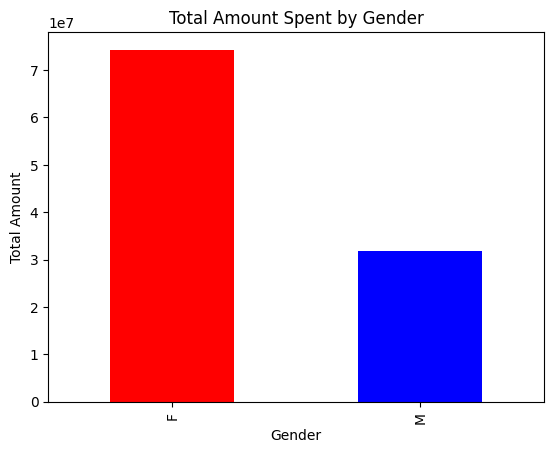

In [9]:
sum_amount=(Diwali_df.groupby('Gender')['Amount'].sum())
print(sum_amount)
(sum_amount.plot.bar(color=['red','blue']))
plt.xlabel('Gender')
plt.ylabel('Total Amount')
plt.title('Total Amount Spent by Gender')
plt.show()

# **3. Count of each age group with individual count of age group wrt gender**

In [10]:
age_gender_count = Diwali_df.groupby(['Age Group', 'Gender'])['Gender'].count()

print(age_gender_count)

Age Group  Gender
0-17       F          162
           M          134
18-25      F         1305
           M          573
26-35      F         3266
           M         1270
36-45      F         1577
           M          705
46-50      F          693
           M          290
51-55      F          553
           M          276
55+        F          272
           M          155
Name: Gender, dtype: int64


# **4. Plot the total amt spent by each age group**

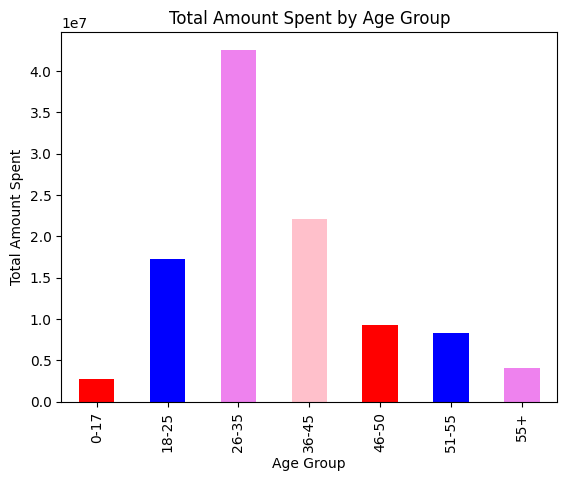

In [11]:
age_group_total_Amount =Diwali_df.groupby('Age Group')['Amount'].sum()
age_group_total_Amount.plot.bar(color=['red','blue','violet','pink'])
plt.xlabel('Age Group')
plt.ylabel('Total Amount Spent')
plt.title('Total Amount Spent by Age Group')
plt.show()

# **5. Plot the graph that depicts total number of orders from top 10 states**

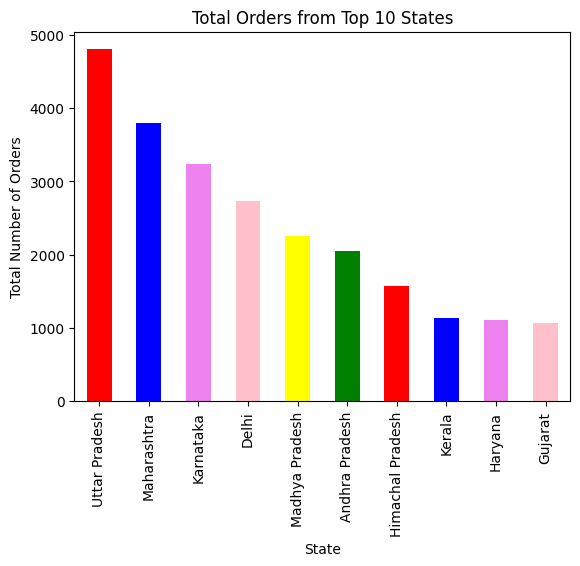

In [12]:
top_10_states = Diwali_df.groupby('State')['Orders'].sum().nlargest(10)
top_10_states.plot.bar(color=['red','blue','violet','pink','yellow','green'])
plt.xlabel('State')
plt.ylabel('Total Number of Orders')
plt.title('Total Orders from Top 10 States')
plt.show()

# **6. Total amt of top 10 states**

,Amount
State,
Uttar Pradesh,19346055.00
Maharashtra,14404467.00
Karnataka,13523540.00
Delhi,11603819.45
Madhya Pradesh,8101142.00
Andhra Pradesh,8037146.99
Himachal Pradesh,4963368.00
Haryana,4217871.00
Bihar,4014669.00


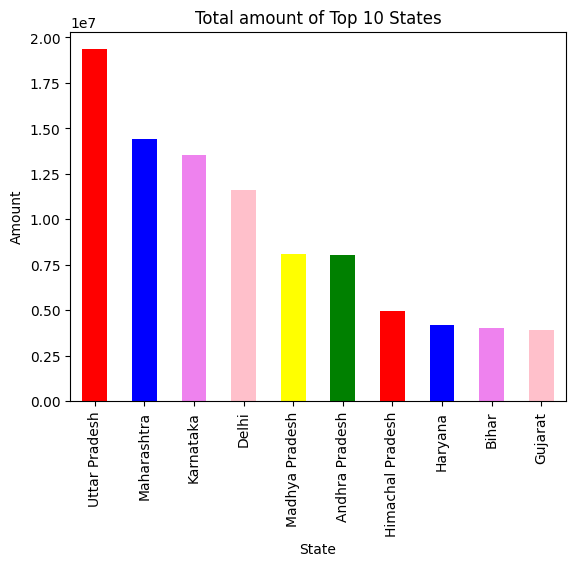

In [13]:
state_amount = Diwali_df.groupby('State')['Amount'].sum().nlargest(10)
display(state_amount)
state_amount.plot.bar(color=['red','blue','violet','pink','yellow','green'])
plt.xlabel('State')
plt.ylabel('Amount')
plt.title('Total amount of Top 10 States')
plt.show()


# **7. Plot me a graph that shows comparison between no of married and unmarried people**

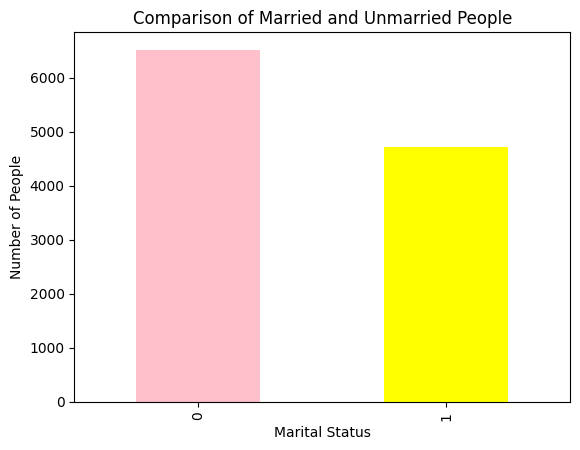

In [14]:
marital_counts = Diwali_df['Marital_Status'].value_counts()
marital_counts.plot.bar(color=['pink','yellow'])
plt.xlabel('Marital Status')
plt.ylabel('Number of People')
plt.title('Comparison of Married and Unmarried People')
plt.show()

# **8. Plot me amt spent by each male and each femlae wrt to marital status**

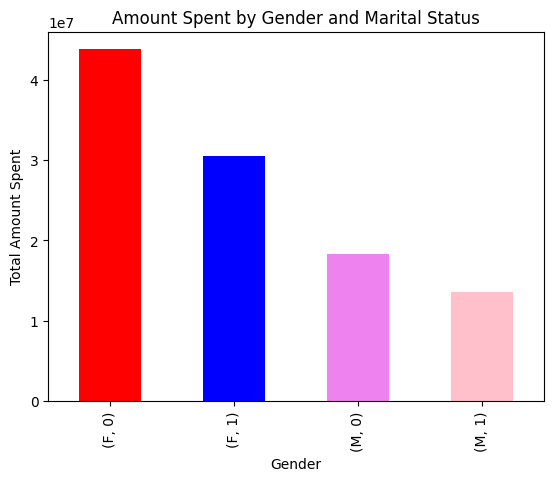

In [15]:
gender_marital_amount =Diwali_df.groupby(['Gender', 'Marital_Status'])['Amount'].sum()
gender_marital_amount.plot.bar(color=['red','blue','violet','pink'])
plt.xlabel('Gender')
plt.ylabel('Total Amount Spent')
plt.title('Amount Spent by Gender and Marital Status')
plt.show()

# **9. Plot me the count of each occupation that is present in dataset**

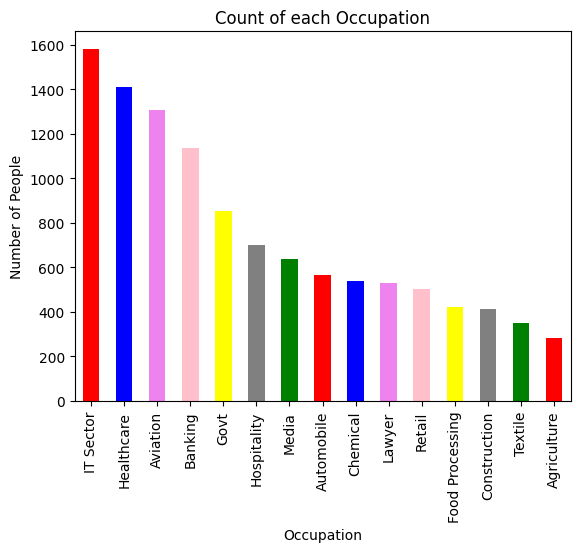

In [16]:
occupation_counts = Diwali_df['Occupation'].value_counts()
occupation_counts.plot.bar(color=['red','blue','violet','pink','yellow','grey','green'])
plt.xlabel('Occupation')
plt.ylabel('Number of People')
plt.title('Count of each Occupation')
plt.show()

# **10. Plot the amt spent by each occupation in descending order**

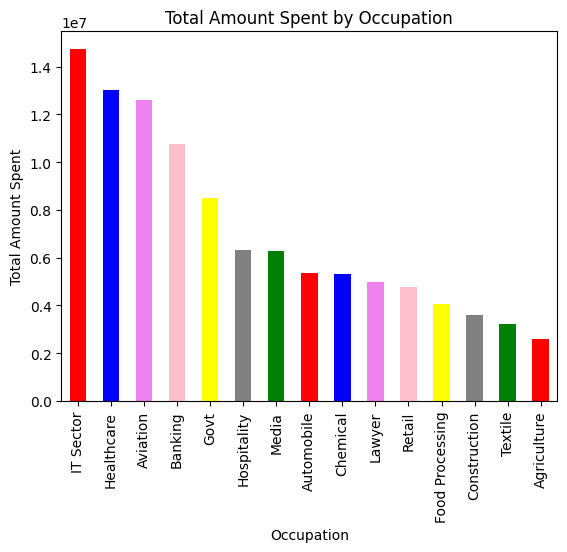

In [21]:
amount_by_occupation=Diwali_df.groupby('Occupation')['Amount'].sum().sort_values(ascending=False)
amount_by_occupation.plot.bar(color=['red','blue','violet','pink','yellow','grey','green'])
plt.xlabel('Occupation')
plt.ylabel('Total Amount Spent')
plt.title('Total Amount Spent by Occupation')
plt.show()

# **11. Plot a graph that provides statistics on the intrest of customers wrt to product category**

In [18]:
fig=px.histogram(Diwali_df,x='Product_Category',title='Intrest of customers wrt to product category',color='Product_Category')
fig.show()

# **12. I would like to know the budget spent on each product category in descending oreder**

,Amount
Product_Category,
Food,33933883.50
Clothing & Apparel,16484472.00
Electronics & Gadgets,15607657.00
Footwear & Shoes,15575209.45
Furniture,5440051.99
Games & Toys,4331694.00
Sports Products,3635933.00
Beauty,1959484.00
Auto,1935041.99


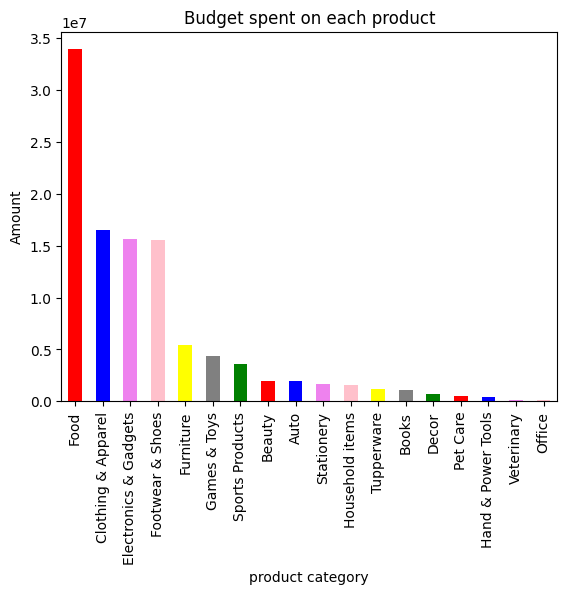

In [19]:
sum_amount1 = Diwali_df.groupby('Product_Category')['Amount'].sum().sort_values(ascending=False)
display(sum_amount1)
sum_amount1.plot.bar(color=['red','blue','violet','pink','yellow','grey','green'])
plt.xlabel('product category')
plt.ylabel('Amount')
plt.title('Budget spent on each product')
plt.show()



# **13. Provide me statical analysis of each product based upon the percentage of orders that has been completed**

,Orders
Product_Category,
Auto,0.851368
Beauty,3.884815
Books,0.876409
Clothing & Apparel,23.705956
Decor,0.840637
Electronics & Gadgets,18.629941
Food,21.856555
Footwear & Shoes,9.465212
Furniture,3.180111


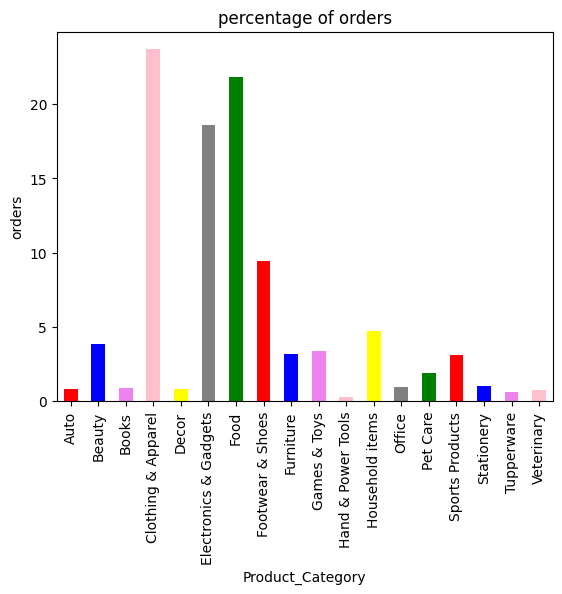

In [20]:
product_analysis = Diwali_df.groupby('Product_Category')['Orders'].sum() / Diwali_df['Orders'].sum() * 100
display(product_analysis)
product_analysis.plot.bar(color=['red','blue','violet','pink','yellow','grey','green'])
plt.xlabel('Product_Category')
plt.ylabel('orders')
plt.title('percentage of orders')
plt.show()

# **14. Conclude that what you have understand form above dataset and give an detail explanation**

*  **Gender Participation**: Females are more actively
engaged in Diwali shopping compared to males
* **Age Group**: The age group of 26-35 years is particularly prominent among female shoppers during Diwali.  
* **Geographic Trend**: Uttar Pradesh leads in terms of product orders for Diwali, followed by Maharashtra, which ranks second in order volume.   
* **Expenditure by Occupation**: Individuals employed in the IT sector are the highest spenders during Diwali. In contrast, those in the agriculture sector tend to spend the least. Occupations in the IT and healthcare sectors are particularly active in Diwali shopping.   
*  **Product Preferences**: Clothing and apparel are the most favored product categories among consumers.
*  **Budget Allocation**: The expenditure on products is prioritized in the following descending order: food, clothing and apparel, followed by Electronics & Gadgets and Footwear & Shoes.






# **15. Key Findings and Business Recommendations**

**Data cleaning:** dropped 12 rows with missing Amount and 8 duplicate rows. 11,231 records and 13 columns remained.

**Findings**
* Women contribute about 70% of total spend (74.3M vs 31.9M for men), roughly 2.3 times as much.
* The 26-35 age group is the largest buying segment.
* Uttar Pradesh, Maharashtra and Karnataka lead among states.
* Food is the top product category by spend, followed by Clothing & Apparel, Electronics & Gadgets and Footwear & Shoes.
* IT sector customers are the highest-spending occupation.

**Recommendations**
1. Target women aged 26-35 with festive campaigns, since they are the biggest and highest-spending segment.
2. Prioritize the top states (Uttar Pradesh, Maharashtra, Karnataka) for ad budget and early stock allocation.
3. Build festive bundles around Food and Clothing, and cross-sell Electronics and Footwear.
4. Run separate offers for lower-spend segments (for example men and older age groups) to test whether spend can grow there.

**Limitations:** This is a descriptive analysis of one festive season, so it shows what happened, not why.